In [9]:
import numpy as np
import matplotlib.pyplot as plt
from pricing_engine.options import EuropeanOption
from pricing_engine.plots import plot_payoff_profit_decay

In [10]:
call_option = EuropeanOption(S=100, K=105, T=1.0, r=0.05, sigma=0.20, option_type='call')

bs_val, bs_t = call_option.price_black_scholes()
mc_val, mc_t = call_option.price_monte_carlo(simulations=50000, seed=42)
bt_val, bt_t = call_option.price_binomial_tree(steps=1000)

print(f"Black-Scholes: ${bs_val:.4f} (calc in {bs_t:.5f}s)")
print(f"Monte Carlo:   ${mc_val:.4f} (calc in {mc_t:.5f}s)")
print(f"Binomial Tree: ${bt_val:.4f} (calc in {bt_t:.5f}s)")

Black-Scholes: $8.0214 (calc in 0.00041s)
Monte Carlo:   $8.0369 (calc in 0.00252s)
Binomial Tree: $8.0211 (calc in 0.00746s)


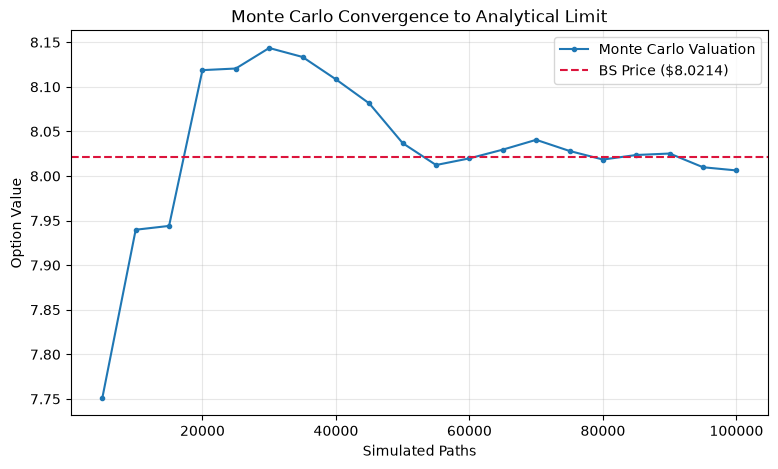

In [11]:
sim_points = np.arange(5000, 105000, 5000)
mc_prices = [call_option.price_monte_carlo(simulations=n, seed=42)[0] for n in sim_points]

plt.figure(figsize=(9, 5))
plt.plot(sim_points, mc_prices, marker='o', markersize=3, label='Monte Carlo Valuation')
plt.axhline(bs_val, color='crimson', linestyle='--', label=f'BS Price (${bs_val:.4f})')
plt.xlabel('Simulated Paths')
plt.ylabel('Option Value')
plt.title('Monte Carlo Convergence to Analytical Limit')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

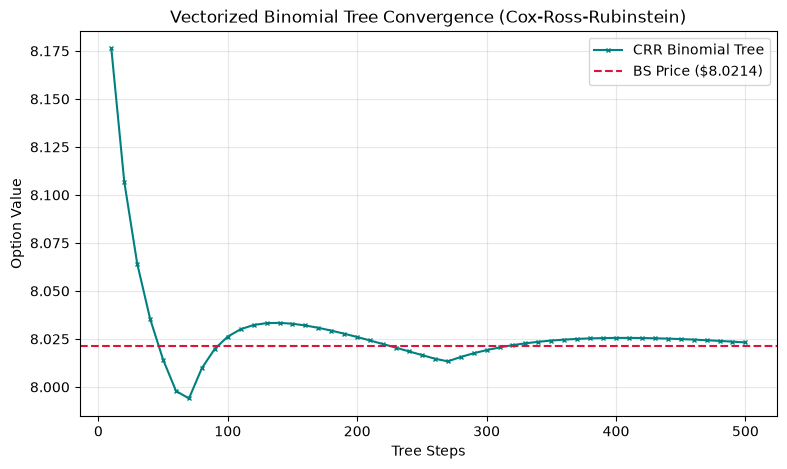

In [12]:
step_points = np.arange(10, 510, 10)
bt_prices = [call_option.price_binomial_tree(steps=n)[0] for n in step_points]

plt.figure(figsize=(9, 5))
plt.plot(step_points, bt_prices, marker='x', markersize=3, color='teal', label='CRR Binomial Tree')
plt.axhline(bs_val, color='crimson', linestyle='--', label=f'BS Price (${bs_val:.4f})')
plt.xlabel('Tree Steps')
plt.ylabel('Option Value')
plt.title('Vectorized Binomial Tree Convergence (Cox-Ross-Rubinstein)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

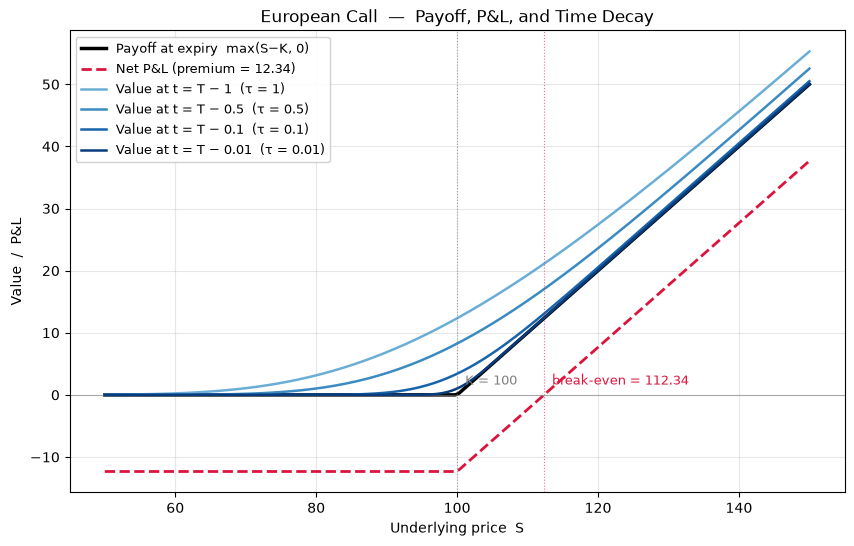

In [15]:
# Generate diagrams for Call option decay snapshots
call_option = EuropeanOption(S=100, K=100, T=1.0, r=0.05, sigma=0.25, option_type='call')
plot_payoff_profit_decay(call_option, times_before_expiry=[1.0, 0.5, 0.1, 0.01])
plt.show()

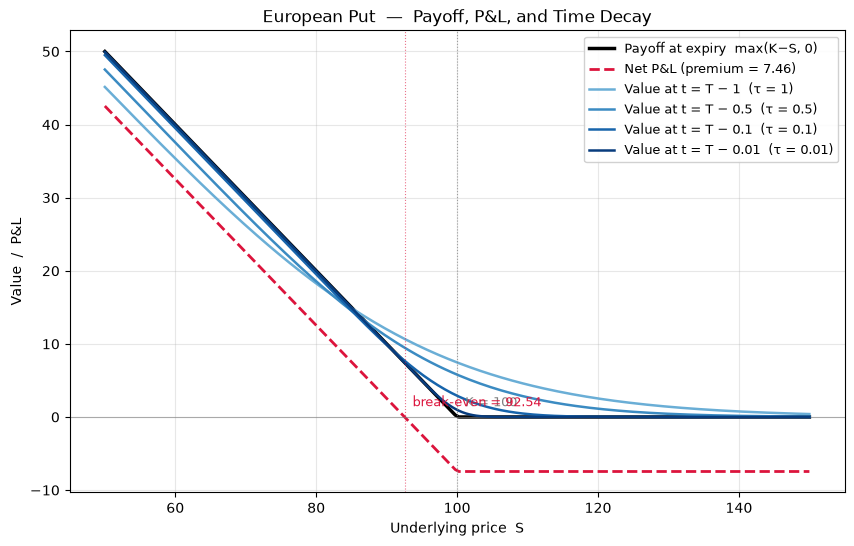

In [14]:
# Generate diagrams for Put option decay snapshots
put_option = EuropeanOption(S=100, K=100, T=1.0, r=0.05, sigma=0.25, option_type='put')
plot_payoff_profit_decay(put_option, times_before_expiry=[1.0, 0.5, 0.1, 0.01])
plt.show()

In [6]:
def print_comparison_table(opt):
    rows = [
        ('Delta', opt.delta(),  opt.delta_fd()),
        ('Gamma', opt.gamma(),  opt.gamma_fd()),
        ('Vega',  opt.vega(),   opt.vega_fd()),
        ('Theta', opt.theta(),  opt.theta_fd()),
        ('Rho',   opt.rho(),    opt.rho_fd()),
    ]
    print(f"{'Risk Greek':<12} {'Analytical':>14} {'Numerical':>14} {'Abs Error':>12}")
    print('=' * 56)
    for name, ana, num in rows:
        print(f"{name:<12} {ana:>14.6f} {num:>14.6f} {abs(ana - num):>12.2e}")

print_comparison_table(call_option)

Risk Greek       Analytical      Numerical    Abs Error
Delta              0.542228       0.542228     5.06e-09
Gamma              0.019835       0.019835     3.49e-08
Vega              39.670524      39.670524     1.65e-08
Theta             -6.277126      -6.277126     4.02e-09
Rho               46.201481      46.201481     4.58e-09
